# Superdense Coding Protocol

Alice codifica dos bits clásicos (b1, b0) sobre su mitad de un par de Bell compartido y se los envía a Bob enviándole un único qubit. Bob mide en la base de Bell y recupera los dos bits originales, que comparamos con los que introdujo Alice.

## Libraries

In [22]:
from qiskit import QuantumCircuit, transpile, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

from IPython.display import display, Markdown


## Helpful functions

In [23]:
def _latex_label(state):
    """Map state identifier to Unicode-friendly label."""
    return {"phi+": "Φ+"}[state]


def _read_bit(prompt):
    """Ask the user for a single classical bit (0 or 1), re-prompting on bad input."""
    while True:
        raw = input(prompt).strip()
        if raw in ("0", "1"):
            return int(raw)
        print("Input not valid: introduce 0 or 1.")


## Definition of Φ+ Bell State Quantum Circuit (shared EPR resource)

In [24]:
def build_bell_circuit(state):
    """
    Build the quantum circuit for the specified Bell state.

    The construction follows two steps:
        1. Hadamard on qubit 0  →  creates superposition |+⟩ on q_0
        2. CNOT (q0 → q1)       →  entangles both qubits

    Additional single-qubit corrections are applied before H to reach
    the other three Bell states:
        |Φ-⟩  →  Z on q_0 after H  (phase flip)
        |Ψ+⟩  →  X on q_1 before H  (bit flip on target)
        |Ψ-⟩  →  X on q_1 + Z on q_0

    Args:
        state: One of "phi+", "phi-", "psi+", "psi-". Defaults to "phi+".

    Returns:
        QuantumCircuit: Parameterised circuit with 2 qubits and 2 classical bits.

    Raises:
        ValueError: If an unknown state label is provided.
    """
    valid = {"phi+", "phi-", "psi+", "psi-"}
    if state not in valid:
        raise ValueError(f"Unknown Bell state '{state}'. Choose from {valid}.")

    qc = QuantumCircuit(2, name=f"Bell |{_latex_label(state)}⟩")


    # ── Step 1: optional pre-corrections ────────────────────────────────────
    if state in ("psi+", "psi-"):
        # Flip target qubit so entanglement produces |01⟩ + |10⟩ basis
        qc.x(1)

    # ── Step 2: Hadamard on control qubit ───────────────────────────────────
    # H |0⟩ = (|0⟩ + |1⟩) / √2  →  equal superposition
    qc.h(0)

    # ── Step 3: optional phase flip ─────────────────────────────────────────
    if state in ("phi-", "psi-"):
        # Z introduces a relative phase: H Z |0⟩ = (|0⟩ - |1⟩) / √2
        qc.z(0)

    # ── Step 4: CNOT — creates entanglement ─────────────────────────────────
    # If q0 = |1⟩, flip q1.  Result: correlated |00⟩ + |11⟩ (or |01⟩ + |10⟩)
    qc.cx(0, 1)

    return qc

## Superdense Coding Quantum Circuit

In [25]:
def build_superdense_coding_circuit(bit1, bit0, epr_state="phi+"):
    """
    Build the quantum circuit for the Superdense Coding protocol.

        1. Bell state preparation (q0 and q1)  →  shared entangled pair
           between Alice (q0) and Bob (q1)
        2. Alice's encoding on q0: applies X if bit0 == 1, then Z if
           bit1 == 1, according to the two classical bits she wants
           to send
        3. Alice sends her qubit q0 to Bob (no gate — from this point
           on Bob holds both qubits)
        4. Bob's Bell-basis measurement: CNOT (q0 → q1), Hadamard on
           q0, then measurement of both qubits recovers (bit1, bit0)

    Encoding table (Alice's gate → resulting Bell state):
        b1 b0   Gate      Resulting state
         0  0   I          |Φ+⟩
         0  1   X          |Ψ+⟩
         1  0   Z          |Φ-⟩
         1  1   Z then X   |Ψ-⟩ (up to global phase)

    Args:
        bit1: first classical bit (0 or 1) Alice wants to send.
        bit0: second classical bit (0 or 1) Alice wants to send.
        epr_state: Bell state "phi+" used as the shared resource.

    Returns:
        QuantumCircuit: Parameterised circuit with 2 qubits and 2
        classical bits. c[0] carries the recovered bit1, c[1] the
        recovered bit0.

    Raises:
        ValueError: If bit1/bit0 are not 0 or 1, or epr_state is invalid.
    """
    valid = {"phi+"}
    if epr_state not in valid:
        raise ValueError(f"Invalid EPR state \'{epr_state}\'. Choose from {valid}.")

    for name, bit in (("bit1", bit1), ("bit0", bit0)):
        if bit not in (0, 1):
            raise ValueError(f"{name} must be 0 or 1, got {bit}.")

    qr = QuantumRegister(2, name="q")
    cr = ClassicalRegister(2, name="c")
    qc_superdense = QuantumCircuit(qr, cr, name="Superdense Coding")

    # Step 1: shared Bell pair — Alice keeps q0, Bob keeps q1
    qc_superdense.append(build_bell_circuit(epr_state), [0, 1])
    qc_superdense.barrier()

    # Step 2: Alice encodes (bit1, bit0) on her qubit q0
    if bit0 == 1:
        qc_superdense.x(0)
    if bit1 == 1:
        qc_superdense.z(0)
    qc_superdense.barrier()

    # Step 3: Alice sends q0 to Bob (implicit)

    # Step 4: Bob\'s Bell-basis measurement
    qc_superdense.cx(0, 1)
    qc_superdense.h(0)

    qc_superdense.measure(0, 0)  # c[0] -> recovered bit1
    qc_superdense.measure(1, 1)  # c[1] -> recovered bit0

    return qc_superdense


## Choose the two bits to send

In [26]:
EPR_state = "phi+".strip()

bit1 = _read_bit("Introduce the first bit  b1 (0/1): ")
bit0 = _read_bit("Introduce the second bit b0 (0/1): ")

print(f"Bits to codify by Alice: b1={bit1}  b0={bit0}")


Bits to codify by Alice: b1=0  b0=1


## Build the Quantum Circuit and draw it

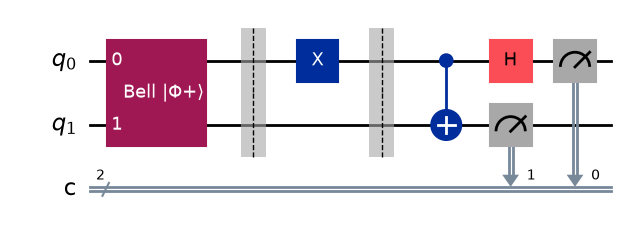

In [27]:
qc_superdense = build_superdense_coding_circuit(bit1, bit0, EPR_state)
fig_superdense = qc_superdense.draw(output="mpl", fold=-1)
fig_superdense


## Execute the Circuit

In [28]:
backend = AerSimulator()

# Transpile and execute (protocol is deterministic -> 1 shot is enough)
transpiled = transpile(qc_superdense, backend, optimization_level=1)
result = backend.run(transpiled, shots=1).result()
counts = result.get_counts()

# Qiskit reports bitstrings as "c[1]c[0]" (rightmost char = lowest classical bit index)
bitstring = list(counts.keys())[0]
recovered_bit1 = int(bitstring[-1])
recovered_bit0 = int(bitstring[0])

## Check the results: compare Alice's bits with Bob's recovered bits

In [29]:
match = (recovered_bit1 == bit1) and (recovered_bit0 == bit0)

print(f"\n{'='*50}")
print(f"Superdense Coding Protocol")
print(f"{'='*50}")

print(f"\nBell State/ EPR State — {_latex_label(EPR_state)}")

print("\n--- Bob's Measurement in Bell basis ---")
print(f"Counts: {counts}")
print(f"Bits recovered: b1={recovered_bit1}  b0={recovered_bit0}")

print("\n--- Comparison ---")
print(f"Bits sent by Alice:    ({bit1}, {bit0})")
print(f"Bits recovered by Bob:   ({recovered_bit1}, {recovered_bit0})")
print(f"Match: {'YES' if match else 'NO'}")



Superdense Coding Protocol

Bell State/ EPR State — Φ+

--- Bob's Measurement in Bell basis ---
Counts: {'10': 1}
Bits recovered: b1=0  b0=1

--- Comparison ---
Bits sent by Alice:    (0, 1)
Bits recovered by Bob:   (0, 1)
Match: YES
